# E-Commerce Customer & Sales Analytics Project

## Python Data Analysis

This notebook analyzes the Kaggle Online Retail dataset using Python. The goal is to identify sales trends, top customers, top products, country performance, monthly revenue trends, and customer segments.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
sales = pd.read_csv(r"C:\Users\prach\OneDrive\Desktop\Data Analytics\PROJECTS\Online Retail\Data\Cleaned_Online_Retail.csv")

In [3]:
sales.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,581587,22631,CIRCUS PARADE LUNCH BOX,12,12/9/2011 12:50:00,1.95,12680,France,23.4
1,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,12/9/2011 12:50:00,1.65,12680,France,19.8
2,581587,22555,PLASTERS IN TIN STRONGMAN,12,12/9/2011 12:50:00,1.65,12680,France,19.8
3,581587,22728,ALARM CLOCK BAKELIKE PINK,4,12/9/2011 12:50:00,3.75,12680,France,15.0
4,581587,22727,ALARM CLOCK BAKELIKE RED,4,12/9/2011 12:50:00,3.75,12680,France,15.0


In [4]:
sales.shape

(392732, 9)

In [5]:
sales.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')

In [6]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392732 entries, 0 to 392731
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392732 non-null  int64  
 1   StockCode    392732 non-null  object 
 2   Description  392732 non-null  object 
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  object 
 5   UnitPrice    392732 non-null  float64
 6   CustomerID   392732 non-null  int64  
 7   Country      392732 non-null  object 
 8   Revenue      392732 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 27.0+ MB


In [7]:
sales.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Revenue
count,392732.000000,392732.000000,392732.000000,392732.000000,392732.000000
mean,560591.072436,13.153718,3.125596,15287.734822,22.629195
std,13087.116747,181.588420,22.240725,1713.567773,311.083465
min,536365.000000,1.000000,0.000000,12346.000000,0.000000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,1.950000,15150.000000,12.390000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000


In [8]:
sales["CustomerID"].isna().sum()

np.int64(0)

In [9]:
sales["Description"].isna().sum()

np.int64(0)

In [10]:
(sales["Quantity"] < 0).sum()

np.int64(0)

In [11]:
(sales["UnitPrice"] <= 0).sum()

np.int64(40)

In [12]:
sales = sales[sales["UnitPrice"] > 0]

In [13]:
(sales["UnitPrice"] <= 0).sum()

np.int64(0)

In [14]:
sales["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(0)

In [15]:
invalid_price_rows = sales[sales["UnitPrice"] <= 0]

invalid_price_rows.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [16]:
sales = sales[sales["UnitPrice"] > 0]

In [17]:
(sales["UnitPrice"] <= 0).sum()

np.int64(0)

In [18]:
sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]

In [19]:
sales[["Quantity", "UnitPrice", "Revenue"]].head()

,Quantity,UnitPrice,Revenue
0,12,1.95,23.4
1,12,1.65,19.8
2,12,1.65,19.8
3,4,3.75,15.0
4,4,3.75,15.0


In [20]:
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"], errors="coerce")

In [21]:
sales["InvoiceDate"].head()

0   2011-12-09 12:50:00
1   2011-12-09 12:50:00
2   2011-12-09 12:50:00
3   2011-12-09 12:50:00
4   2011-12-09 12:50:00
Name: InvoiceDate, dtype: datetime64[ns]

In [22]:
sales["InvoiceDate"].isna().sum()

np.int64(0)

In [23]:
sales["OrderYear"] = sales["InvoiceDate"].dt.year
sales["OrderMonthNumber"] = sales["InvoiceDate"].dt.month
sales["OrderMonthName"] = sales["InvoiceDate"].dt.month_name()
sales["OrderDayName"] = sales["InvoiceDate"].dt.day_name()

In [24]:
sales[["InvoiceDate", "OrderYear", "OrderMonthNumber", "OrderMonthName", "OrderDayName"]].head()

,InvoiceDate,OrderYear,OrderMonthNumber,OrderMonthName,OrderDayName
0,2011-12-09 12:50:00,2011,12,December,Friday
1,2011-12-09 12:50:00,2011,12,December,Friday
2,2011-12-09 12:50:00,2011,12,December,Friday
3,2011-12-09 12:50:00,2011,12,December,Friday
4,2011-12-09 12:50:00,2011,12,December,Friday


In [25]:
total_revenue = sales["Revenue"].sum()

total_revenue

np.float64(8887208.894000001)

In [26]:
total_orders = sales["InvoiceNo"].nunique()

total_orders

18532

In [27]:
total_customers = sales["CustomerID"].nunique()

total_customers

4338

In [28]:
average_order_value = total_revenue / total_orders

average_order_value

np.float64(479.56016047917126)

In [29]:
kpi_summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Total Orders", "Total Customers", "Average Order Value"],
    "Value": [total_revenue, total_orders, total_customers, average_order_value]
})

kpi_summary

,Metric,Value
0,Total Revenue,8.887209e+06
1,Total Orders,1.853200e+04
2,Total Customers,4.338000e+03
3,Average Order Value,4.795602e+02


In [30]:
top_10_countries = (
    sales.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_10_countries

,Country,Revenue
0,United Kingdom,7285024.644
1,Netherlands,285446.340
2,EIRE,265262.460
3,Germany,228678.400
4,France,208934.310
5,Australia,138453.810
6,Spain,61558.560
7,Switzerland,56443.950
8,Belgium,41196.340
9,Sweden,38367.830


In [31]:
top_customers = (
    sales.groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique")
    )
    .sort_values("Total_Revenue", ascending=False)
    .head(20)
    .reset_index()
)

top_customers

,CustomerID,Total_Revenue,Total_Orders
0,14646,280206.02,73
1,18102,259657.30,60
2,17450,194390.79,46
3,16446,168472.50,2
4,14911,143711.17,201
5,12415,124914.53,21
6,14156,117210.08,55
7,17511,91062.38,31
8,16029,80850.84,63
9,12346,77183.60,1


In [32]:
monthly_revenue = (
    sales.groupby(["OrderYear", "OrderMonthNumber", "OrderMonthName"])["Revenue"]
    .sum()
    .reset_index()
    .sort_values(["OrderYear", "OrderMonthNumber"])
)

monthly_revenue

,OrderYear,OrderMonthNumber,OrderMonthName,Revenue
0,2010,12,December,570422.730
1,2011,1,January,568101.310
2,2011,2,February,446084.920
3,2011,3,March,594081.760
4,2011,4,April,468374.331
5,2011,5,May,677355.150
6,2011,6,June,660046.050
7,2011,7,July,598962.901
8,2011,8,August,644051.040
9,2011,9,September,950690.202


In [33]:
revenue_by_day = (
    sales.groupby("OrderDayName")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

revenue_by_day

,OrderDayName,Revenue
0,Thursday,1973015.730
1,Tuesday,1697733.801
2,Wednesday,1584283.830
3,Friday,1483080.811
4,Monday,1363604.401
5,Sunday,785490.321


In [34]:
customer_segments = (
    sales.groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

In [35]:
def customer_segment(revenue):
    if revenue >= 10000:
        return "High Value Customer"
    elif revenue >= 3000:
        return "Medium Value Customer"
    else:
        return "Low Value Customer"

customer_segments["Customer_Segment"] = customer_segments["Total_Revenue"].apply(customer_segment)

customer_segments.head()

,CustomerID,Total_Revenue,Total_Orders,Customer_Segment
0,12346,77183.60,1,High Value Customer
1,12347,4310.00,7,Medium Value Customer
2,12348,1797.24,4,Low Value Customer
3,12349,1757.55,1,Low Value Customer
4,12350,334.40,1,Low Value Customer


In [36]:
segment_count = (
    customer_segments["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_count.columns = ["Customer_Segment", "Number_of_Customers"]

segment_count

,Customer_Segment,Number_of_Customers
0,Low Value Customer,3784
1,Medium Value Customer,450
2,High Value Customer,104


In [37]:
segment_revenue = (
    customer_segments.groupby("Customer_Segment")["Total_Revenue"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue

,Customer_Segment,Total_Revenue
0,High Value Customer,3650089.970
1,Low Value Customer,3028163.243
2,Medium Value Customer,2208955.681


In [38]:
os.makedirs("Images", exist_ok=True)
os.makedirs("Python_Output", exist_ok=True)

In [39]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_products["Description"], top_10_products["Revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Images/Python_Top_Products.png")
plt.show()

NameError: name 'top_10_products' is not defined

<Figure size 1000x600 with 0 Axes>

In [40]:
# Create Revenue column first
sales["Revenue"] = sales["Quantity"] * sales["UnitPrice"]

# Create top 10 products by revenue
top_10_products = (
    sales.groupby("Description", as_index=False)["Revenue"]
    .sum()
    .sort_values(by="Revenue", ascending=False)
    .head(10)
)

# Check result
top_10_products

,Description,Revenue
2310,"PAPER CRAFT , LITTLE BIRDIE",168469.60
2756,REGENCY CAKESTAND 3 TIER,142264.75
3687,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
1751,JUMBO BAG RED RETROSPOT,85040.54
1981,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
2599,POSTAGE,77803.96
2335,PARTY BUNTING,68785.23
206,ASSORTED COLOUR BIRD ORNAMENT,56413.03
2119,Manual,53419.93
2644,RABBIT NIGHT LIGHT,51251.24


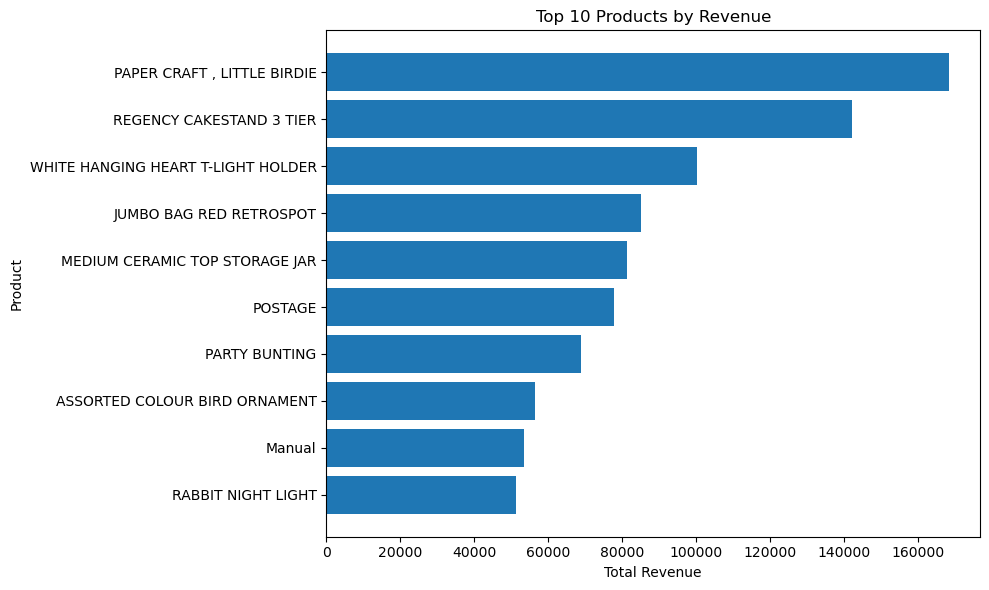

In [41]:
import matplotlib.pyplot as plt
import os

# Create Images folder if it does not exist
os.makedirs("Images", exist_ok=True)

plt.figure(figsize=(10, 6))
plt.barh(top_10_products["Description"], top_10_products["Revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Top 10 Products by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Images/Python_Top_Products.png")
plt.show()

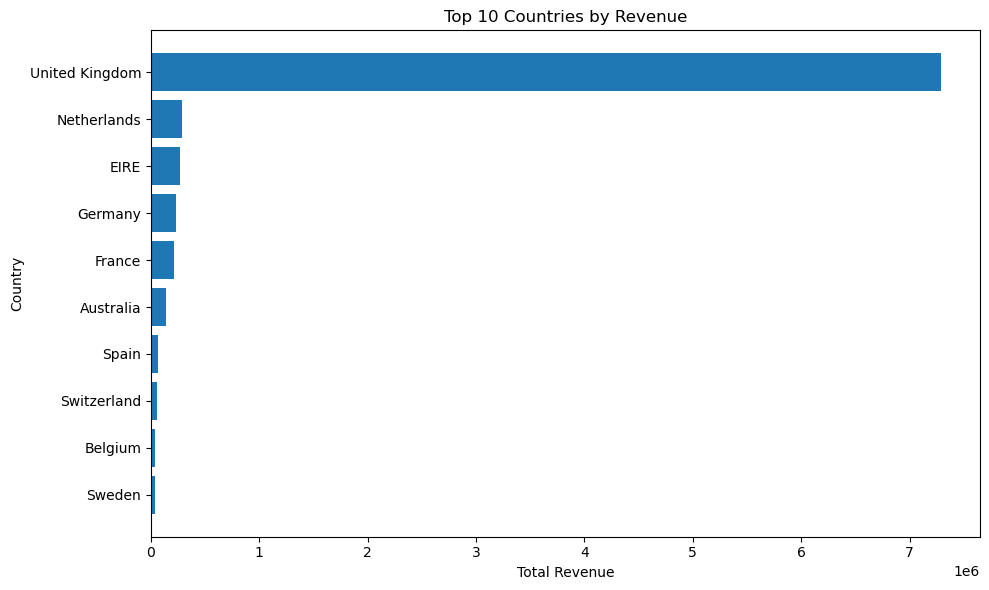

In [42]:
plt.figure(figsize=(10, 6))
plt.barh(top_10_countries["Country"], top_10_countries["Revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Country")
plt.title("Top 10 Countries by Revenue")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Images/Python_Top_Countries.png")
plt.show()

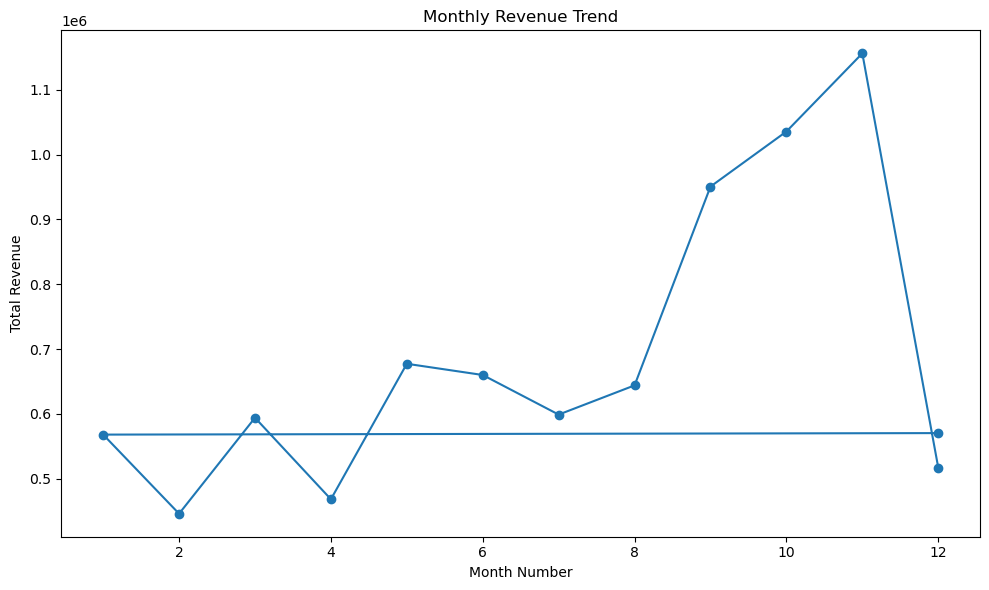

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(monthly_revenue["OrderMonthNumber"], monthly_revenue["Revenue"], marker="o")
plt.xlabel("Month Number")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.savefig("Images/Python_Monthly_Revenue.png")
plt.show()

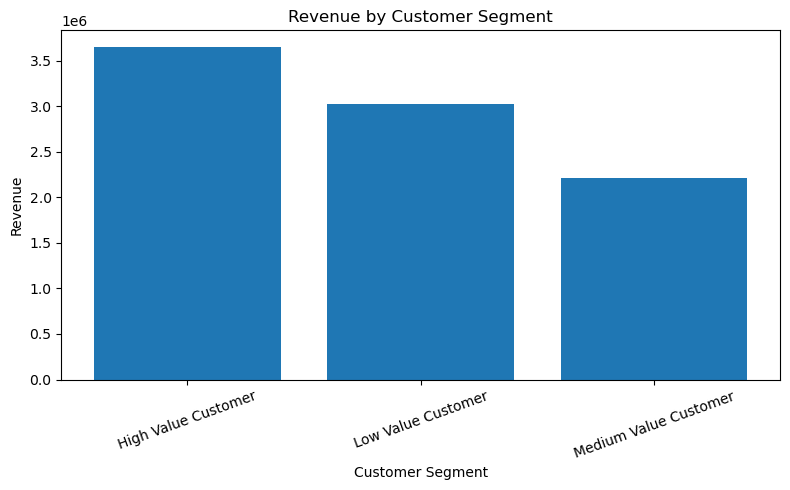

In [44]:
plt.figure(figsize=(8, 5))
plt.bar(segment_revenue["Customer_Segment"], segment_revenue["Total_Revenue"])
plt.xlabel("Customer Segment")
plt.ylabel("Revenue")
plt.title("Revenue by Customer Segment")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("Images/Python_Customer_Segment_Revenue.png")
plt.show()

In [45]:
kpi_summary.to_csv("Python_Output/kpi_summary.csv", index=False)
top_10_countries.to_csv("Python_Output/top_10_countries.csv", index=False)
top_10_products.to_csv("Python_Output/top_10_products.csv", index=False)
top_customers.to_csv("Python_Output/top_customers.csv", index=False)
monthly_revenue.to_csv("Python_Output/monthly_revenue.csv", index=False)
customer_segments.to_csv("Python_Output/customer_segments.csv", index=False)
segment_count.to_csv("Python_Output/segment_count.csv", index=False)
segment_revenue.to_csv("Python_Output/segment_revenue.csv", index=False)

In [46]:
sales.to_csv("Python_Output/cleaned_online_retail_python.csv", index=False)